# Week3 (Regression) 과제
## Boston Housing Data 분석
### 데이터 소개
- **CRIM**: Per capita crime rate by town.
- **ZN**: Proportion of residential land zoned for lots over 25,000 square feet.
- **INDUS**: Proportion of non-retail business acres per town.
- **CHAS**: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise).
- **NOX**: Nitric oxide concentration (parts per 10 million).
- **RM**: Average number of rooms per dwelling.
- **AGE**: Proportion of owner-occupied units built prior to 1940.
- **DIS**: Weighted distances to five Boston employment centers.
- **RAD**: Index of accessibility to radial highways.
- **TAX**: Full-value property tax rate per $10,000.
- **PTRATIO**: Pupil-teacher ratio by town.
- **B**: 1000(Bk - 0.63)^2 where Bk is the proportion of Black residents by town.
- **LSTAT**: Percentage of lower status of the population.

Target Variable:
- **MEDV**: Median value of owner-occupied homes in $1000s.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.font_manager as fm

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

# 그래프 한글 깨짐 방지
malgun_path = r"C:\Windows\Fonts\malgun.ttf"
fm.fontManager.addfont(malgun_path)
plt.rcParams['font.family'] = fm.FontProperties(fname=malgun_path).get_name()
plt.rcParams['axes.unicode_minus'] = False

In [4]:
# housing.xls가 포함된 경로를 저장해봅시다.
PATH = 'C:\\Users\\user\\Desktop\\머신러닝 방학 세션\\과제\\housing.xls'

In [5]:
# 본인 구글 드라이브에 업로드한 housing.xls 파일의 주소를 넣어주세요!
house = pd.read_excel(PATH)

# Q1: `head`, `info`, `describe`, `shape` 함수를 실행해봅시다.

과제2 참고

In [6]:
house.head()

house.info()

house.describe()

house.shape

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


(506, 14)

# Q2: 각 변수의 결측치 (NaN 또는 Null)의 개수를 구해봅시다.

과제2 참고

NaN 형태의 명시적 결측치는 없는 것으로 보인다.

In [7]:
# NaN의 개수 구하기
house.isnull().sum()


CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

# Q3: 각 변수별로 히스토그램을 그리고, Scatterplot Matrix를 그려봅시다

과제2 참고

전반적으로 14개 변수 대부분이 정규분포보다는 한쪽으로 치우친 분포를 보인다. CRIM(범죄율)과 ZN(대형부지 zoning 비율)은 대부분의 지역이 0에 가까운 값에 몰려있고 극소수 지역만 매우 큰 값을 가지는 극단적인 오른쪽 치우침을 보이며, DIS(고용중심지까지 거리)와 LSTAT(저소득층 비율)도 비슷하게 낮은 값에 다수가 몰리고 소수만 큰 값을 갖는 오른쪽 치우침 형태다. 반대로 AGE(오래된 주택 비율)와 B는 왼쪽이 아니라 높은 값 쪽에 스파이크가 몰려있는 분포로, AGE는 95~100% 구간에 지역이 많이 몰려 오래된 주택이 대부분인 지역이 많다는 것을 보여주고, B는 최댓값 근처에 대부분의 지역이 몰려있어 대부분 지역의 흑인 인구 비율이 매우 낮다는 것을 시사한다.

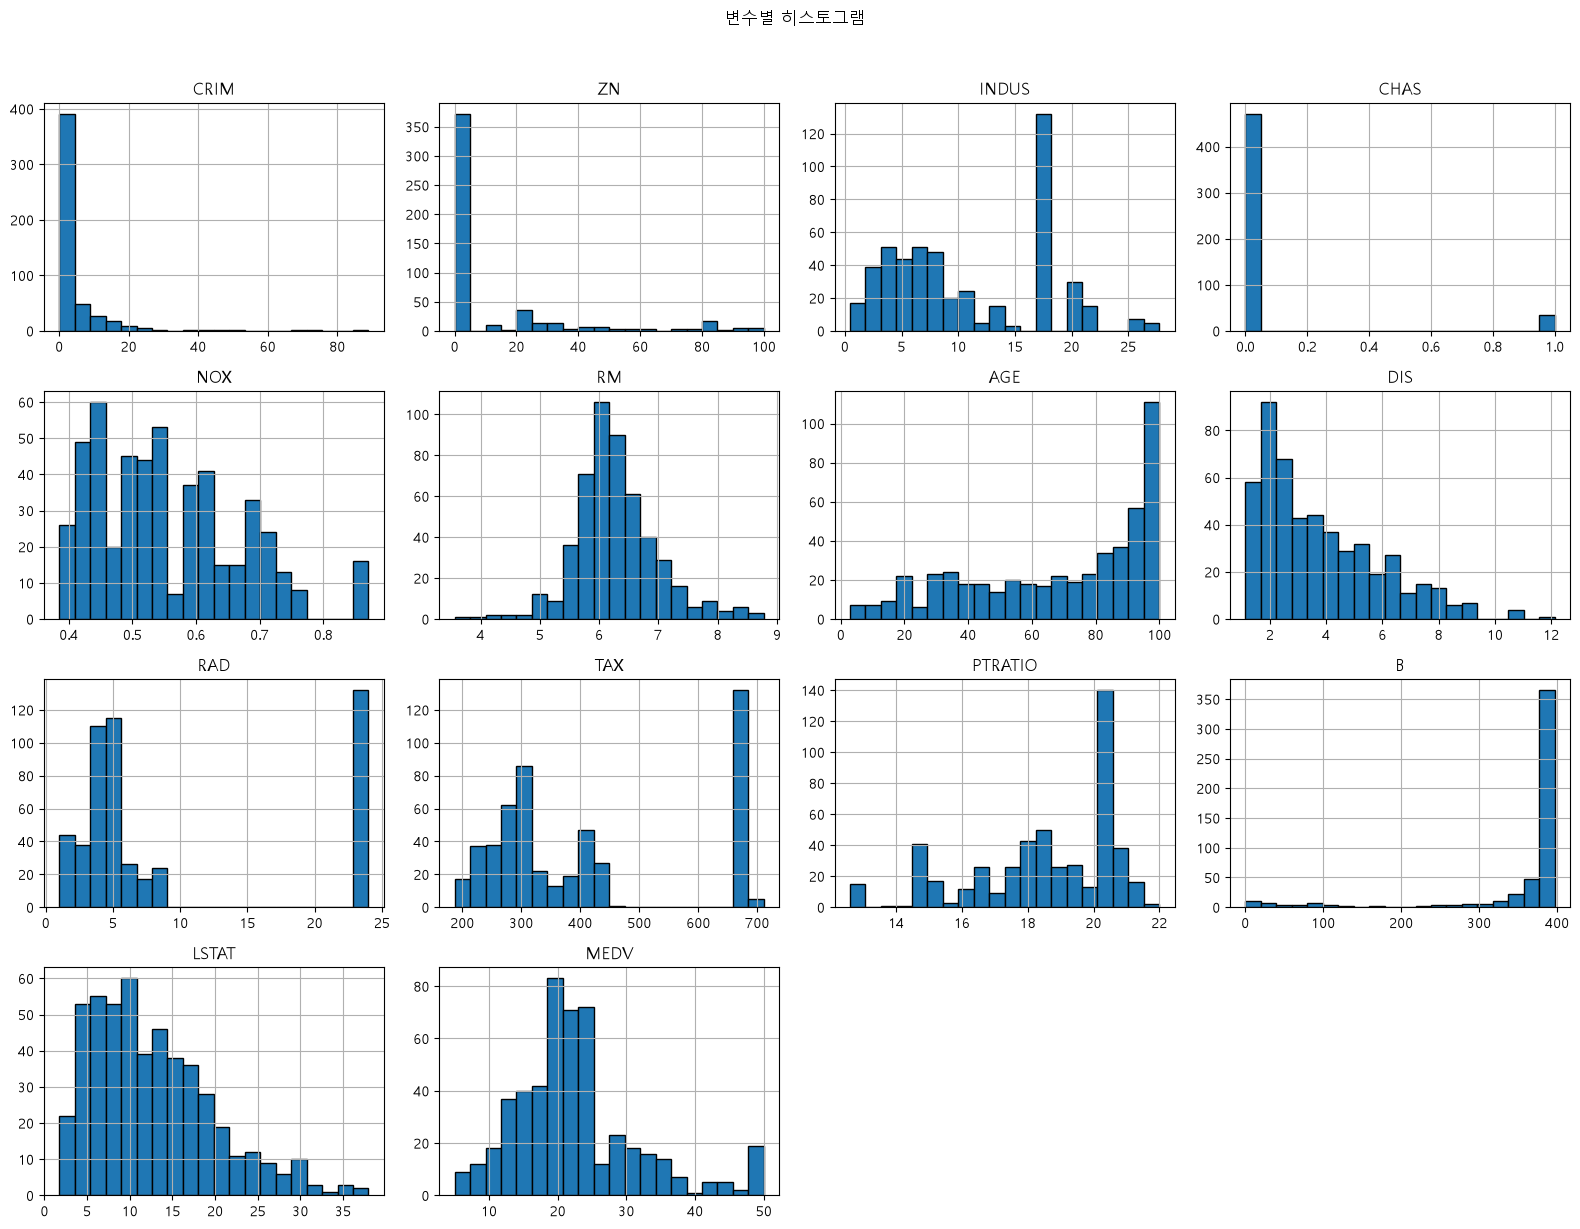

In [8]:
# Histogram
house.hist(bins=20, figsize=(16, 12), edgecolor='black')
plt.suptitle('변수별 히스토그램', y=1.02)
plt.tight_layout()
plt.show()

"상관관계 히트맵을 보면 MEDV와 가장 강하게 연관된 변수는 LSTAT(-0.74)와 RM(0.70)이며, scatterplot matrix에서도 이 두 변수만 뚜렷한 (LSTAT는 비선형, RM은 선형) 추세를 보인다. PTRATIO, INDUS, TAX는 상관계수 자체는 3~5위권이지만 실제 산점도상으로는 관계가 뚜렷하지 않고 산발적으로 흩어져 있다

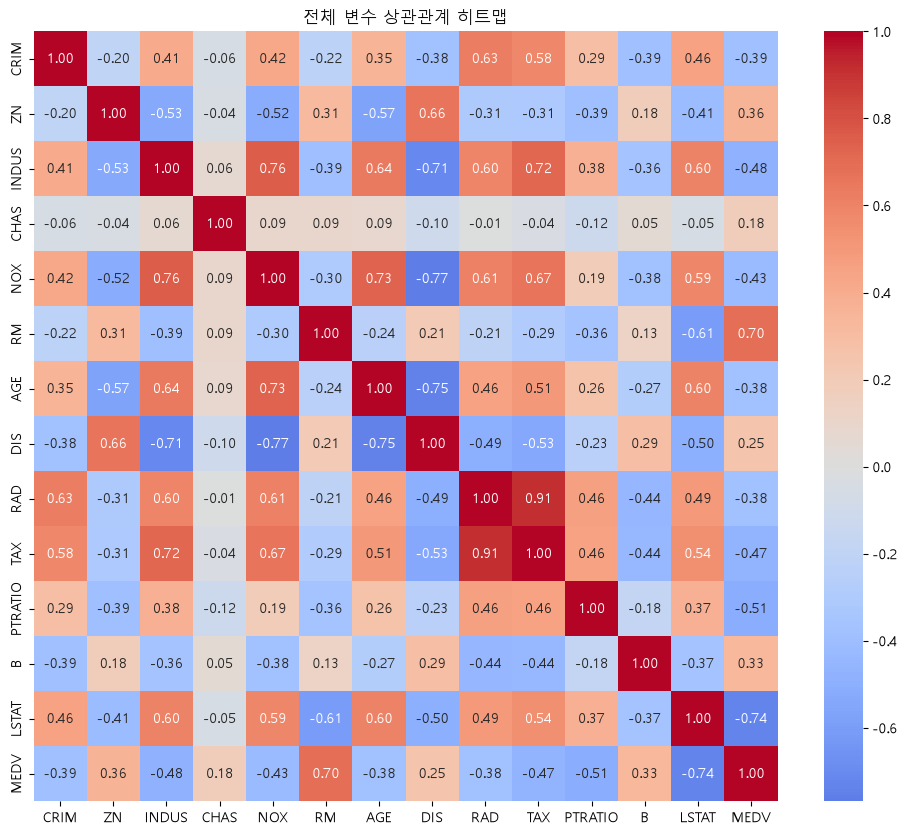

MEDV와 상관관계 상위 5개 변수: ['LSTAT', 'RM', 'PTRATIO', 'INDUS', 'TAX']


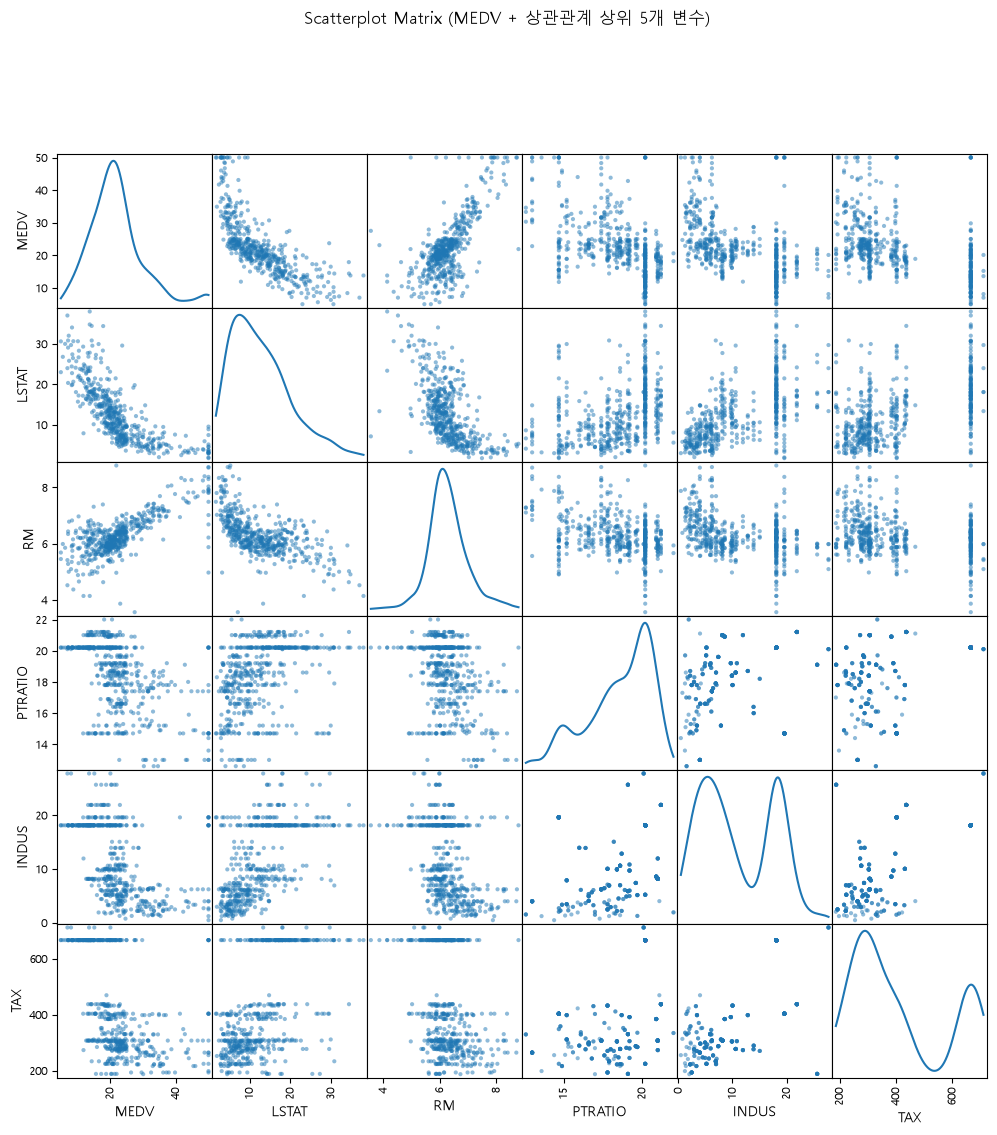

In [9]:
# Scatterplot Matrix
# 14개 변수 전체를 다 넣으면(196칸) 너무 무겁고 가시성이 떨어지므로,
# 1) 먼저 상관관계 히트맵으로 전체를 빠르게 훑고
# 2) MEDV와 상관관계가 높은 상위 변수들만 뽑아서 작은 scatterplot matrix로 자세히 봄

# 1) 상관관계 히트맵 (전체 14개 변수, 빠르고 한눈에 보임)
plt.figure(figsize=(12, 10))
corr = house.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('전체 변수 상관관계 히트맵')
plt.show()

# 2) MEDV와 상관관계가 높은 상위 5개 변수만 뽑아서 작은 Scatterplot Matrix
top_corr_features = corr['MEDV'].drop('MEDV').abs().sort_values(ascending=False).head(5).index.tolist()
print('MEDV와 상관관계 상위 5개 변수:', top_corr_features)

subset_cols = ['MEDV'] + top_corr_features
pd.plotting.scatter_matrix(house[subset_cols], figsize=(12, 12), diagonal='kde', alpha=0.5)
plt.suptitle('Scatterplot Matrix (MEDV + 상관관계 상위 5개 변수)', y=1.0)
plt.show()

## Q3-1. 다중공선성(multicolinearity)을 확인하기 위해 VIF를 추가로 확인해봅시다.

첫 VIF 계산 결과, CRIM(2.13)·ZN(2.91)·CHAS(1.18)를 제외한 나머지 11개 변수 모두 일반적인 다중공선성 기준(VIF>10)을 초과했으며, 특히 RM(136.10), PTRATIO(87.23), NOX(74.00), TAX(61.94)는 극단적으로 높게 나타났다. 이 중 RM의 VIF가 가장 높아, Q3-2에서 우선적으로 제거할 변수로 선택했다

In [21]:
# 그대로 실행하기 !!
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['VIF Factor'] = [variance_inflation_factor(house.values, i) for i in range(house.shape[1])]
vif['features'] = house.columns
vif 

,VIF Factor,features
0,2.131404,CRIM
1,2.910004,ZN
2,14.485874,INDUS
3,1.176266,CHAS
4,74.004269,NOX
5,136.101743,RM
6,21.398863,AGE
7,15.430455,DIS
8,15.369980,RAD
9,61.939713,TAX


## Q3-2. 
VIF가 높은 변수가 하나씩 줄어들면 다른 변수들의 VIF에도 영향을 미치기 때문에 변수들을 한 번에 다 제거하기보다는 하나씩 제거하면서 확인해 나아가는 것이 바람직합니다! 여러 차례 VIF를 확인해보면서 변수를 제거해보세요!

VIF 기반으로 변수를 반복 제거한 결과, 초기에는 CRIM·ZN·CHAS를 제외한 거의 모든 변수(11개)가 VIF 10을 초과했으며 RM(136.10)이 가장 심각했다. RM을 제거하자 일부 변수는 소폭 개선됐지만 대부분 여전히 높은 수준을 유지했고, 이어서 PTRATIO를 제거하자 DIS가 처음으로 10 아래로 내려왔다. NOX를 추가로 제거한 뒤에는 TAX(54.75)가 가장 두드러지게 높게 나타났으며, 마지막으로 TAX까지 제거하자 INDUS·DIS·RAD가 모두 10 이하의 안정적인 수준으로 떨어졌다.

총 4개 변수(RM, PTRATIO, NOX, TAX)를 순차적으로 제거한 결과, 대부분의 변수는 다중공선성이 크게 완화되었으나 AGE(16.45)와 B(18.13)는 여전히 10을 상당히 웃돌고 있으며, LSTAT(10.93)와 MEDV(11.39)도 경계선을 살짝 넘는 수준이다. 따라서 다중공선성 문제가 소수 변수에 국한되지 않고 여러 변수에 걸쳐 폭넓게 존재했음을 확인할 수 있었으며, 완전히 10 이하로 수렴시키려면 AGE, B 등을 추가로 제거하는 반복 과정이 더 필요해 보인다.

In [25]:
vif = pd.DataFrame()
x_data = house.drop(columns=['RM', 'PTRATIO', 'NOX', 'TAX'])  # 지금까지 제거한 변수들을 계속 리스트에 누적
vif["VIF Factor"] = [variance_inflation_factor(x_data.values, i) for i in range(x_data.shape[1])]
vif["features"] = x_data.columns
vif


,VIF Factor,features
0,2.103261,CRIM
1,2.465535,ZN
2,9.024818,INDUS
3,1.142745,CHAS
4,16.449470,AGE
5,8.722321,DIS
6,4.858231,RAD
7,18.131319,B
8,10.934458,LSTAT
9,11.385287,MEDV


**house 데이터셋에 변수 제거를 적용하지 않고 우선 진행하세요! 추후에 MSE 비교를 통해 변수 제거를 확실히 해봅시다.**

# Q4: 데이터를 `X_train`, `X_test`, `y_train`, `y_test` 로 split해 봅시다

split 비율은 자유롭게 정해보시기 바랍니다.

데이터가 506개라 8:2로 하면 train 405개, test 101개로 적당히 나뉘어서 무난하다.

In [27]:
# train_test_split
# 지시대로 아직 다중공선성 변수는 제거하지 않고 원본 13개 피처를 그대로 사용
X = house.drop(columns='MEDV')
y = house['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (404, 13)
X_test shape: (102, 13)
y_train shape: (404,)
y_test shape: (102,)


# Q5: `StandardScaler`로 표준화를 해봅시다

CRIM, ZN, INDUS, NOX, RM, AGE, DIS, TAX, PTRATIO, B, LSTAT 변수들만 `StandardScaler`을 해봅시다. (이들 중 다중공선성으로 인해 제거한 변수들이 있다면 제외하고 진행해주세요.)

`X_train`은 `fit_transform`, `X_test`는 `transform`을 이용하는 것에 유의합시다!

In [28]:
# StandardScaler
# CHAS(더미변수), RAD(범주형에 가까운 지수)는 스케일링 대상에서 제외
scale_cols = ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'TAX', 'PTRATIO', 'B', 'LSTAT']

scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])  # 훈련 데이터: 기준 계산 + 적용
X_test[scale_cols] = scaler.transform(X_test[scale_cols])        # 테스트 데이터: 훈련 기준으로 적용만

X_train.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
477,1.287702,-0.500320,1.033237,0,0.489252,-1.428069,1.028015,-0.802173,24,1.578434,0.845343,-0.074337,1.753505
15,-0.336384,-0.500320,-0.413160,0,-0.157233,-0.680087,-0.431199,0.324349,4,-0.584648,1.204741,0.430184,-0.561474
332,-0.403253,1.013271,-0.715218,0,-1.008723,-0.402063,-1.618599,1.330697,1,-0.602724,-0.637176,0.065297,-0.651595
423,0.388230,-0.500320,1.033237,0,0.489252,-0.300450,0.591681,-0.839240,24,1.578434,0.845343,-3.868193,1.525387
19,-0.325282,-0.500320,-0.413160,0,-0.157233,-0.831094,0.033747,-0.005494,4,-0.584648,1.204741,0.379119,-0.165787


# Q6: 5-fold Cross-Validation으로 `LinearRegression`을 적합해봅시다.

각 fold마다 적합 후 MSE, MAE, RMSE, $R^2$를 구하고, coefficient과 intercept를 `print` 해보세요.

fold별 결과를 보면 성능 편차가 상당히 크다는 점이 눈에 띈다. 특히 fold 3(MSE=36.47, R²=0.59)과 fold 5(MSE=12.51, R²=0.81)는 같은 모델·같은 데이터셋에서 나온 결과라고 보기 어려울 정도로 차이가 크며, 이는 두 fold가 우연히 각각 "예측하기 어려운 검증셋"과 "예측하기 쉬운 검증셋"을 뽑았기 때문으로 해석된다. 만약 5-fold가 아니라 단 한 번의 train/test 분할만으로 평가했다면, 어떤 분할이 뽑혔는지에 따라 모델 성능에 대한 판단이 완전히 달라졌을 수 있다.

5개 fold의 결과를 평균 냄으로써(MSE=24.32, R²=0.72) 극단적으로 좋았던 값과 나빴던 값이 서로 상쇄되어, 특정 분할 하나의 "운"에 좌우되지 않는 더 안정적인 성능 추정치를 얻을 수 있었다. 이는 데이터를 어떻게 나누느냐가 모델 성능 자체보다 "평가의 신뢰도"에 더 큰 영향을 줄 수 있다는 것을 보여주는 사례이며, 여러 번 반복 검증하는 것이 왜 중요한지를 뒷받침한다

또한 fold별 회귀계수(coefficient)를 비교해보면 완전히 동일하지 않고 fold마다 값이 다소 변동하는 것을 확인할 수 있다. 이는 어떤 데이터로 학습하느냐에 따라 모델이 학습하는 계수 자체도 어느 정도 불안정할 수 있음을 시사하며, 특히 앞서 VIF 분석에서 다중공선성이 확인됐던 만큼 이런 계수 변동성이 그 영향과 무관하지 않을 가능성도 있다.

In [29]:
# KFold, cross_val_score, cross_validation 이용
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

q6_mse, q6_mae, q6_rmse, q6_r2 = [], [], [], []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train), start=1):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = LinearRegression()
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)

    mse = mean_squared_error(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_val, y_pred)

    q6_mse.append(mse)
    q6_mae.append(mae)
    q6_rmse.append(rmse)
    q6_r2.append(r2)

    print(f'[Fold {fold}]')
    print(f'  MSE: {mse:.4f}  MAE: {mae:.4f}  RMSE: {rmse:.4f}  R2: {r2:.4f}')
    print(f'  Coefficients: {model.coef_}')
    print(f'  Intercept: {model.intercept_:.4f}')
    print()

print('=== 5-Fold 평균 (Q6, 원본 13개 피처) ===')
print(f'평균 MSE : {np.mean(q6_mse):.4f}')
print(f'평균 MAE : {np.mean(q6_mae):.4f}')
print(f'평균 RMSE: {np.mean(q6_rmse):.4f}')
print(f'평균 R2  : {np.mean(q6_r2):.4f}')

[Fold 1]
  MSE: 23.2864  MAE: 3.2108  RMSE: 4.8256  R2: 0.6725
  Coefficients: [-0.94812889  0.75860569  0.30089583  3.00762597 -2.22748976  3.51291195
 -0.0701652  -3.21933289  0.22020054 -1.4566606  -2.08154936  1.15725598
 -3.28121084]
  Intercept: 20.5048

[Fold 2]
  MSE: 23.5646  MAE: 3.4965  RMSE: 4.8543  R2: 0.7601
  Coefficients: [-1.05807326  0.74220183  0.10490298  3.09299413 -2.01430949  2.79994632
 -0.17481654 -3.32611962  0.24295321 -1.74209102 -1.77657178  1.09336037
 -3.97212925]
  Intercept: 20.1013

[Fold 3]
  MSE: 36.4745  MAE: 3.7736  RMSE: 6.0394  R2: 0.5895
  Coefficients: [-0.83960069  0.68397371  0.56370453  0.62831766 -1.64117107  3.49407283
 -0.31189726 -2.65099913  0.22502761 -2.05077    -2.18048357  1.23827918
 -2.99696129]
  Intercept: 20.5784

[Fold 4]
  MSE: 25.7558  MAE: 3.9217  RMSE: 5.0750  R2: 0.7592
  Coefficients: [-1.0337213   0.32691448 -0.03308526  4.61419375 -1.99624146  2.92001074
 -0.29251259 -2.88703739  0.28517372 -1.4279188  -2.13511308  1.0

### Q6-1: 다중공선성이 높았던 변수를 제거한 후 다시 train_test_split, scaler, 5-fold CV 과정으로 `LinearRegression`을 적합한 후 Q6에서 구한 평균 MSE(or MAE, RMSE, $R^2$)와 비교해보세요.

Q6-1 결과, 다중공선성이 높았던 4개 변수(RM, PTRATIO, NOX, TAX)를 제거하자 오히려 성능이 악화되었다(MSE 24.32→33.27, R² 0.72→0.62). 그 이유는 이 변수들이 VIF 기준으로는 문제였지만, 실제로는 MEDV와 상관관계가 강한(RM 0.70, PTRATIO -0.51, TAX -0.47 등) 유효한 예측 변수였기 때문이다. VIF는 예측 변수들 간의 중복 정보만 진단할 뿐 타깃과의 관계는 전혀 고려하지 않으므로, VIF가 높다는 이유만으로 변수를 제거하면 오히려 유용한 예측 정보를 잃을 수 있다는 것을 이번 비교를 통해 확인할 수 있었다. 다중공선성은 예측 성능보다는 회귀계수의 해석과 안정성에 더 큰 영향을 미치는 문제이며, 예측이 목적이라면 VIF 기준의 기계적 변수 제거보다 실제 성능 비교를 통한 검증이 필요함을 보여주는 결과다.

In [31]:
# 다중공선성을 불러일으키는 변수 제거
house_new = house.drop(['RM', 'PTRATIO', 'NOX', 'TAX'], axis=1) # VIF 높은 변수들 기입

In [32]:
# train_test_split
X_new = house_new.drop(columns='MEDV')
y_new = house_new['MEDV']

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.2, random_state=42)


# StandardScaler
scale_cols_new = ['CRIM', 'ZN', 'INDUS', 'AGE', 'DIS', 'B', 'LSTAT']  # 제거된 RM, PTRATIO, NOX, TAX는 목록에서 제외

scaler_new = StandardScaler()
X_train_new[scale_cols_new] = scaler_new.fit_transform(X_train_new[scale_cols_new])
X_test_new[scale_cols_new] = scaler_new.transform(X_test_new[scale_cols_new])


# KFold, cross_val_score, cross_validation 이용
kf_new = KFold(n_splits=5, shuffle=True, random_state=42)

q6_1_mse, q6_1_mae, q6_1_rmse, q6_1_r2 = [], [], [], []

for fold, (train_idx, val_idx) in enumerate(kf_new.split(X_train_new), start=1):
    X_tr, X_val = X_train_new.iloc[train_idx], X_train_new.iloc[val_idx]
    y_tr, y_val = y_train_new.iloc[train_idx], y_train_new.iloc[val_idx]

    model = LinearRegression()
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)

    mse = mean_squared_error(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_val, y_pred)

    q6_1_mse.append(mse)
    q6_1_mae.append(mae)
    q6_1_rmse.append(rmse)
    q6_1_r2.append(r2)

    print(f'[Fold {fold}]')
    print(f'  MSE: {mse:.4f}  MAE: {mae:.4f}  RMSE: {rmse:.4f}  R2: {r2:.4f}')
    print(f'  Coefficients: {model.coef_}')
    print(f'  Intercept: {model.intercept_:.4f}')
    print()

print('=== 5-Fold 평균 (Q6-1, 다중공선성 변수 4개 제거 후 9개 피처) ===')
print(f'평균 MSE : {np.mean(q6_1_mse):.4f}')
print(f'평균 MAE : {np.mean(q6_1_mae):.4f}')
print(f'평균 RMSE: {np.mean(q6_1_rmse):.4f}')
print(f'평균 R2  : {np.mean(q6_1_r2):.4f}')

print()
print('=== Q6 vs Q6-1 비교 ===')
comparison = pd.DataFrame({
    'Q6 (13개 피처)': [np.mean(q6_mse), np.mean(q6_mae), np.mean(q6_rmse), np.mean(q6_r2)],
    'Q6-1 (9개 피처)': [np.mean(q6_1_mse), np.mean(q6_1_mae), np.mean(q6_1_rmse), np.mean(q6_1_r2)],
}, index=['MSE', 'MAE', 'RMSE', 'R2'])
print(comparison)

[Fold 1]
  MSE: 25.3734  MAE: 3.7915  RMSE: 5.0372  R2: 0.6431
  Coefficients: [-9.92246091e-01  2.01644317e+00 -1.97545164e+00  3.88501666e+00
  6.71464465e-01 -3.91947271e+00  2.85156566e-03  8.35929676e-01
 -6.40414172e+00]
  Intercept: 22.4785

[Fold 2]
  MSE: 41.3104  MAE: 4.4516  RMSE: 6.4273  R2: 0.5794
  Coefficients: [-9.39582327e-01  1.77912297e+00 -1.81878032e+00  4.24822476e+00
  2.68687418e-01 -3.46853416e+00 -5.23277073e-03  8.77644269e-01
 -6.19916981e+00]
  Intercept: 22.3767

[Fold 3]
  MSE: 38.3394  MAE: 4.4901  RMSE: 6.1919  R2: 0.5685
  Coefficients: [-0.91094253  1.86294725 -1.59599424  2.79066814  0.01554102 -3.83169849
 -0.02706162  0.69983592 -6.23671918]
  Intercept: 22.8689

[Fold 4]
  MSE: 39.4734  MAE: 4.7620  RMSE: 6.2828  R2: 0.6309
  Coefficients: [-1.02280276  1.2945287  -1.80901322  5.2939029  -0.02548955 -3.38098339
  0.04971027  0.8280244  -6.30315622]
  Intercept: 21.9126

[Fold 5]
  MSE: 21.8484  MAE: 3.6572  RMSE: 4.6742  R2: 0.6703
  Coefficients:

# Q7(Optional): `GridSearchCV`를 이용하여 `Lasso`를 적합해봅시다.

찾아야 하는 최적 파라미터는

- `alpha`: 0.01, 0.1, 1, 10 중에서 찾기
- `fit_intercept`: `True`, `False`에서 찾기

https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter

위 링크를 참조하여 `GridSearCV`의 `scoring`을 3가지 이상 사용해보세요

1) 최적 하이퍼파라미터 및 전반적 경향

최적 조합: alpha=0.01, fit_intercept=True (R²=0.7243)
fit_intercept=True 조건에서는 alpha가 커질수록 R²가 완만히 감소(0.72→0.72→0.65→0.12)하는 자연스러운 패턴을 보임
fit_intercept=False는 전 구간에서 성능이 크게 붕괴(R²=0.22~0.11, 심지어 alpha=10에서는 R²=-2.49로 평균 예측보다도 못함) — 절편 없이 원점을 강제로 지나가게 하면 극단적으로 성능이 나빠질 수 있음을 보여줌


2) alpha에 따른 계수 축소(soft-thresholding) 확인

alpha=0.01: 0/13개 계수가 0 (사실상 OLS와 동일)
alpha=0.1: 2/13개가 0
alpha=1: 8/13개가 0
alpha=10: 12/13개가 0 (RAD 하나만 생존)
예측대로 alpha가 작으면 OLS에 가깝고, 크면 대부분의 계수를 0으로 미는 패턴이 확인됨


3) 문제점 ① — RAD가 끝까지 살아남은 것은 스케일링 미적용에 따른 왜곡

alpha=10에서 유일하게 살아남은 RAD는 MEDV와 상관관계가 특별히 강한 변수가 아님(r≈-0.38)
Lasso는 각 변수의 "신호 강도"가 일정 임계값(threshold=alpha)을 넘는지에 따라 계수를 0으로 만들지 결정하는 soft-thresholding 방식으로 작동하는데, 이 신호 강도 자체가 변수의 원래 스케일에 비례해서 커짐
RAD는 Q5에서 스케일링 대상에서 제외되어 원 단위(1~24)를 그대로 유지했기 때문에, 실제 예측 중요도와 무관하게 신호 강도가 부풀려져 임계값을 넘어 생존한 것으로 해석됨
즉 이 결과는 RAD의 진짜 중요도를 반영한 것이 아니라, 스케일링 파이프라인 설계(CHAS·RAD 제외)와 Lasso가 만나 생긴 왜곡에 가까움


4) 문제점 ② — "예측 성능 기준 최적 alpha"가 다중공선성·해석 문제를 해결해주지는 않음

우리가 사용한 3개 지표(R², MSE, MAE)는 모두 예측 성능만 측정하는 지표이며, 계수의 안정성이나 해석 가능성은 전혀 반영하지 않음
최적으로 선택된 alpha=0.01은 계수가 하나도 0이 되지 않아 사실상 규제가 거의 없는 상태이므로, Q6에서 관찰했던 fold별 계수 불안정성(다중공선성 문제)이 전혀 해소되지 않은 채로 "최적"이라고 선택된 것
즉 이 GridSearchCV 결과는 "예측 정확도만 보면 굳이 규제를 세게 걸 필요가 없다"는 것을 확인해줄 뿐, 해석 가능하고 안정적인 모델을 얻는다는 목적에는 답을 주지 못함


5) alpha=0.01과 alpha=0.1의 차이는 사실상 노이즈 수준

두 alpha의 R² 차이는 0.0044에 불과하며, 이는 Q6에서 관찰된 fold 간 R² 편차(0.59~0.81, 차이 0.22)에 비하면 통계적으로 유의미하다고 보기 어려움

이 기준을 적용하면 alpha=0.1(계수 2개 제거, 성능 차이는 무시할 수준)이 alpha=0.01보다 실질적으로 더 합리적인 선택일 수 있음


In [33]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso

# param_grid
param_grid = {
    'alpha': [0.01, 0.1, 1, 10],
    'fit_intercept': [True, False]
}

# scoring 3가지 이상 사용 (r2, MSE, MAE)
scoring = {
    'R2': 'r2',
    'MSE': 'neg_mean_squared_error',
    'MAE': 'neg_mean_absolute_error'
}

grid_search = GridSearchCV(
    estimator=Lasso(),
    param_grid=param_grid,
    scoring=scoring,
    refit='R2',  # 여러 지표 중 최종 모델 선택 기준을 R2로 지정 (다중 스코어링 시 필수)
    cv=5,
    return_train_score=True
)

grid_search.fit(X_train, y_train)  # 원본 13개 피처(Q5에서 스케일링한 X_train) 그대로 사용

print('=== 최적 하이퍼파라미터 ===')
print(grid_search.best_params_)
print(f'최고 R2 (CV 평균): {grid_search.best_score_:.4f}')
print()

# 8개 조합 전체 결과 표로 정리 (MSE, MAE는 neg_ 값이라 보기 편하게 부호 반전)
results = pd.DataFrame(grid_search.cv_results_)
results['mean_test_MSE'] = -results['mean_test_MSE']
results['mean_test_MAE'] = -results['mean_test_MAE']
cols = ['param_alpha', 'param_fit_intercept', 'mean_test_R2', 'mean_test_MSE', 'mean_test_MAE']
print(results[cols].sort_values('mean_test_R2', ascending=False).round(4).to_string(index=False))
print()

# alpha별로 계수가 몇 개나 정확히 0으로 눌리는지 확인 -> 규제 강도의 변수 선택 효과 직접 확인
best_fit_intercept = grid_search.best_params_['fit_intercept']
print('=== alpha별 계수 변화 (fit_intercept={}) ==='.format(best_fit_intercept))
for alpha in param_grid['alpha']:
    lasso = Lasso(alpha=alpha, fit_intercept=best_fit_intercept)
    lasso.fit(X_train, y_train)
    n_zero = int(np.sum(lasso.coef_ == 0))
    print(f'alpha={alpha:>5} -> 0으로 눌린 계수: {n_zero}/{len(lasso.coef_)}개')
    print(f'  계수: {lasso.coef_.round(3)}')

=== 최적 하이퍼파라미터 ===
{'alpha': 0.01, 'fit_intercept': True}
최고 R2 (CV 평균): 0.7243

 param_alpha  param_fit_intercept  mean_test_R2  mean_test_MSE  mean_test_MAE
        0.01                 True        0.7243        23.6680         3.4398
        0.10                 True        0.7199        24.0450         3.3948
        1.00                 True        0.6457        30.4073         3.8425
        0.01                False        0.2172        66.4071         6.2978
        0.10                False        0.2146        66.5921         6.2828
       10.00                 True        0.1208        75.8212         6.4167
        1.00                False        0.1066        76.0034         6.4717
       10.00                False       -2.4925       300.7668        15.2321

=== alpha별 계수 변화 (fit_intercept=True) ===
alpha= 0.01 -> 0으로 눌린 계수: 0/13개
  계수: [-0.985  0.654  0.205  2.657 -1.96   3.147 -0.149 -3.015  0.25  -1.656
 -2.029  1.122 -3.617]
alpha=  0.1 -> 0으로 눌린 계수: 2/13개
  계수: [-0.

# Q8(Optional): `RandomizedSearchCV`를 이용하여 `Ridge`를 적합해 봅시다.

CV를 이용한 hyperparameter tuning의 또다른 방법은 `RandomizedSearchCV`입니다.
Tuning해야 하는 모수가 많을 경우 이 방법이 빠르다는 장점이 있습니다.

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html#

위 링크를 참조하거나 구글링을 하여 `Ridge`를 적합해보세요.

`n_iter`와, 파라미터 공간을 자유롭게 조정해보세요.

A8. RandomizedSearchCV + Ridge 결과 해석

1) 최적 결과 및 Lasso(Q7)와 비교

최적 하이퍼파라미터: alpha=2.80, fit_intercept=True (R²=0.7249)
Lasso 최적 결과(alpha=0.01, R²=0.7243)와 거의 동일하거나 근소하게 더 나은 성능
주목할 점: Ridge는 Lasso보다 **훨씬 강한 규제(alpha 2.80 vs 0.01)**를 걸었음에도 성능 저하가 전혀 없음

2) 계수가 0으로 눌리지 않는다는 이론이 실제로 확인됨

모든 alpha 값(0.31~2.80 등)에서 0으로 눌린 계수: 0/13개로 일관됨
Ridge는 제곱항 페널티를 쓰기 때문에 이론적으로 계수를 정확히 0으로 만들지 않는데, 이 결과가 그 성질을 그대로 보여줌

3) R²가 넓은 alpha 범위에서 거의 평평함

alpha가 0.31→2.80까지(약 10배 차이) 변해도 R²는 0.7245~0.7249로 사실상 동일
Lasso는 alpha=0.01→0.1로 살짝만 옮겨도 계수 2개가 이미 0으로 눌렸던 것과 대조적
Ridge는 규제 강도 선택에 상대적으로 둔감하고 안정적임을 시사

4) Ridge 계수와 Lasso 계수가 거의 동일한 패턴


Lasso(alpha=0.01): [-0.985  0.654  0.205  2.657 -1.96  3.147 -0.149 -3.015  0.25  -1.656 -2.029  1.122 -3.617]
Ridge(alpha=2.80): [-0.994  0.659  0.239  2.539 -1.935 3.156 -0.172 -2.986  0.253 -1.686 -2.028  1.131 -3.592]
두 벡터의 크기·부호가 거의 일치
Ridge는 상당한 규제를 걸었음에도 OLS/Lasso와 거의 같은 계수 조합에 도달했다는 뜻
결론
Ridge는 Lasso보다 강한 규제를 걸고도 성능 손실이 없었고, 규제 강도에도 덜 민감했으며, 계수를 0으로 만들지 않으면서 원래 관계 구조를 그대로 유지했다. 이는 다중공선성이 있는 이 데이터셋에서 Ridge가 Lasso보다 "성능 손실 없이 계수를 안정화"시키는 데 더 적합한 방법임을 보여준다.



In [34]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import Ridge
from scipy.stats import loguniform

# param_distributions (GridSearchCV의 param_grid에 대응하는 자리, 연속분포 사용 가능)
param_distributions = {
    'alpha': loguniform(1e-2, 1e2),  # 0.01~100 사이를 로그스케일로 연속 샘플링
    'fit_intercept': [True, False]
}

# scoring 3가지 (Q7과 동일하게 맞춰서 비교 가능하도록)
scoring = {
    'R2': 'r2',
    'MSE': 'neg_mean_squared_error',
    'MAE': 'neg_mean_absolute_error'
}

random_search = RandomizedSearchCV(
    estimator=Ridge(),
    param_distributions=param_distributions,
    n_iter=30,          # 30번 무작위로 조합을 뽑아서 시도
    scoring=scoring,
    refit='R2',
    cv=5,
    random_state=42,    # 무작위 샘플링이라 재현성을 위해 반드시 고정
    return_train_score=True
)

random_search.fit(X_train, y_train)  # 원본 13개 피처(Q5에서 스케일링한 X_train) 사용, Q7과 동일 조건

print('=== 최적 하이퍼파라미터 (RandomizedSearchCV, Ridge) ===')
print(random_search.best_params_)
print(f'최고 R2 (CV 평균): {random_search.best_score_:.4f}')
print()

# 상위 10개 조합 결과 확인 (MSE, MAE는 부호 반전해서 보기 편하게)
results = pd.DataFrame(random_search.cv_results_)
results['mean_test_MSE'] = -results['mean_test_MSE']
results['mean_test_MAE'] = -results['mean_test_MAE']
cols = ['param_alpha', 'param_fit_intercept', 'mean_test_R2', 'mean_test_MSE', 'mean_test_MAE']
print(results[cols].sort_values('mean_test_R2', ascending=False).round(4).head(10).to_string(index=False))
print()

# 최적 조합으로 다시 학습해서 계수 확인 -> Ridge는 Lasso와 달리 계수를 0으로 안 만드는지 직접 비교
best_ridge = Ridge(alpha=random_search.best_params_['alpha'], fit_intercept=random_search.best_params_['fit_intercept'])
best_ridge.fit(X_train, y_train)
n_zero = int(np.sum(best_ridge.coef_ == 0))
print(f'최적 Ridge 계수 (0으로 눌린 개수: {n_zero}/{len(best_ridge.coef_)}개)')
print(best_ridge.coef_.round(3))

=== 최적 하이퍼파라미터 (RandomizedSearchCV, Ridge) ===
{'alpha': np.float64(2.7964859516062464), 'fit_intercept': True}
최고 R2 (CV 평균): 0.7249

 param_alpha  param_fit_intercept  mean_test_R2  mean_test_MSE  mean_test_MAE
      2.7965                 True        0.7249        23.6165         3.4271
      2.6926                 True        0.7249        23.6173         3.4278
      2.4810                 True        0.7249        23.6190         3.4293
      1.2563                 True        0.7247        23.6327         3.4386
      0.7363                 True        0.7246        23.6407         3.4428
      0.6672                 True        0.7246        23.6418         3.4434
      0.6072                 True        0.7246        23.6428         3.4438
      0.5762                 True        0.7246        23.6434         3.4441
      0.5343                 True        0.7246        23.6441         3.4445
      0.3149                 True        0.7245        23.6481         3.4463

최적 Rid